In [7]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("izban_data.csv")

In [5]:
df.head()

,date_hours,time_of_day,day_of_week,weekend,station,heat,rains_mm,density_class
0,2025-05-01 00:00:00,0,3,0,Alsancak,20.5,0.0,Sakin
1,2025-05-01 01:00:00,1,3,0,Alsancak,32.2,0.0,Normal
2,2025-05-01 02:00:00,2,3,0,Alsancak,3.9,0.0,Sakin
3,2025-05-01 03:00:00,3,3,0,Alsancak,24.4,7.1,Normal
4,2025-05-01 04:00:00,4,3,0,Bayraklı,22.3,0.0,Sakin


In [6]:
df["station"].value_counts()

station
Nergiz        1135
Çiğli         1133
Bayraklı      1114
Menemen       1092
Egekent       1088
Alsancak      1074
Karşıyaka     1065
Halkapınar    1059
Name: count, dtype: int64

In [8]:
df["weekend"].value_counts()

weekend
0    6264
1    2496
Name: count, dtype: int64

In [9]:
df.describe()

,time_of_day,day_of_week,weekend,heat,rains_mm
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,11.500000,3.000000,0.284932,18.051849,0.591107
std,6.922582,1.997372,0.451408,6.983797,1.768824
min,0.000000,0.000000,0.000000,-7.200000,0.000000
25%,5.750000,1.000000,0.000000,13.300000,0.000000
50%,11.500000,3.000000,0.000000,18.100000,0.000000
75%,17.250000,5.000000,1.000000,22.800000,0.000000
max,23.000000,6.000000,1.000000,44.200000,25.100000


In [10]:
df["heat"].value_counts()

heat
 19.2    67
 18.2    64
 17.2    61
 18.8    60
 16.4    59
         ..
-3.7      1
 39.6     1
-2.7      1
 40.4     1
 34.2     1
Name: count, Length: 424, dtype: int64

In [12]:
sns.set_theme(style="whitegrid")

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_21180\1238784803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="density_class", order=["Sakin", "Normal", "Çok Yoğun"], palette="Set2")


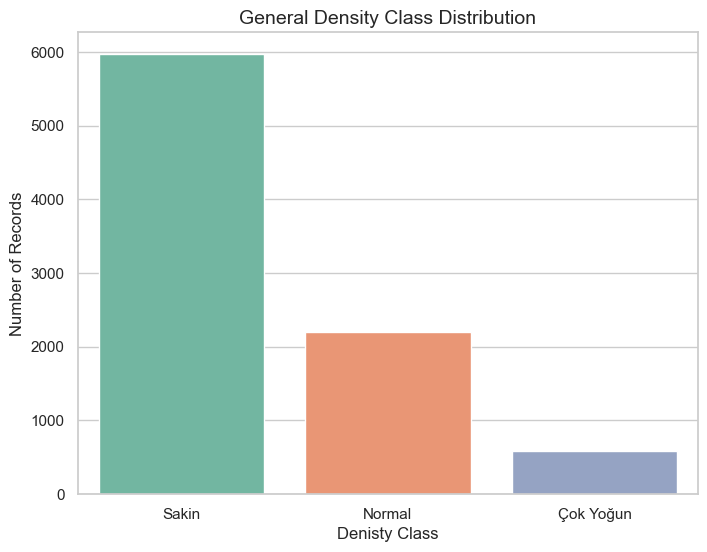

In [17]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="density_class", order=["Sakin", "Normal", "Çok Yoğun"], palette="Set2")
plt.title("General Density Class Distribution", fontsize=14)
plt.xlabel("Denisty Class", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.show()

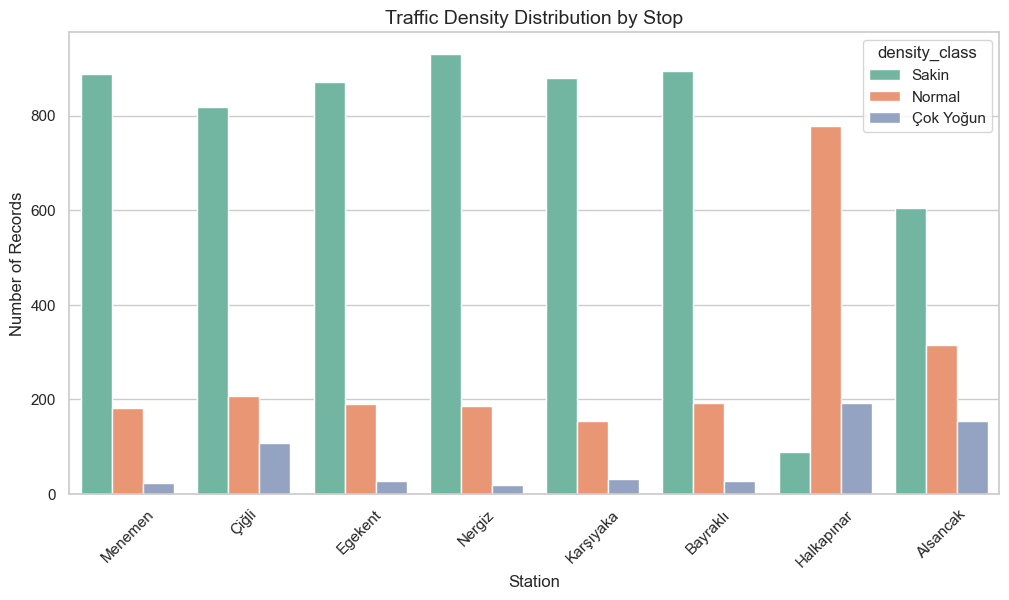

In [16]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="station", hue="density_class", 
              order=["Menemen", "Çiğli", "Egekent", "Nergiz", "Karşıyaka", "Bayraklı", "Halkapınar", "Alsancak"], 
              palette="Set2")
plt.title("Traffic Density Distribution by Stop", fontsize=14)
plt.xlabel("Station", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.xticks(rotation=45)
plt.show()

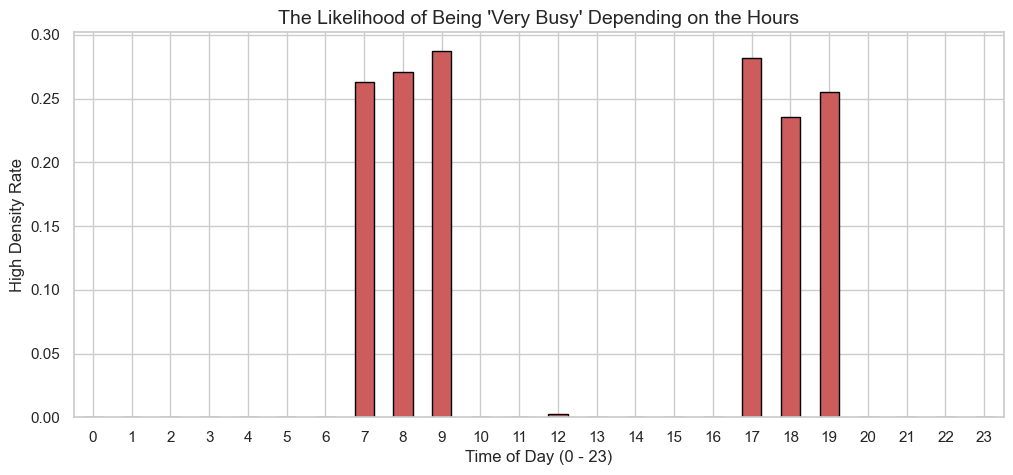

In [19]:
plt.figure(figsize=(12, 5))

peak_df = df.groupby('time_of_day')['density_class'].value_counts(normalize=True).unstack()

if 'Çok Yoğun' in peak_df.columns:
    peak_df["Çok Yoğun"].plot(kind='bar', color='indianred', edgecolor='black')
    plt.title("The Likelihood of Being 'Very Busy' Depending on the Hours", fontsize=14)
    plt.xlabel("Time of Day (0 - 23)", fontsize=12)
    plt.ylabel("High Density Rate", fontsize=12)
    plt.xticks(rotation=0)
    plt.show()

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_21180\1979149662.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="density_class", y="heat", order=["Sakin", "Normal", "Çok Yoğun"], palette='Set2')


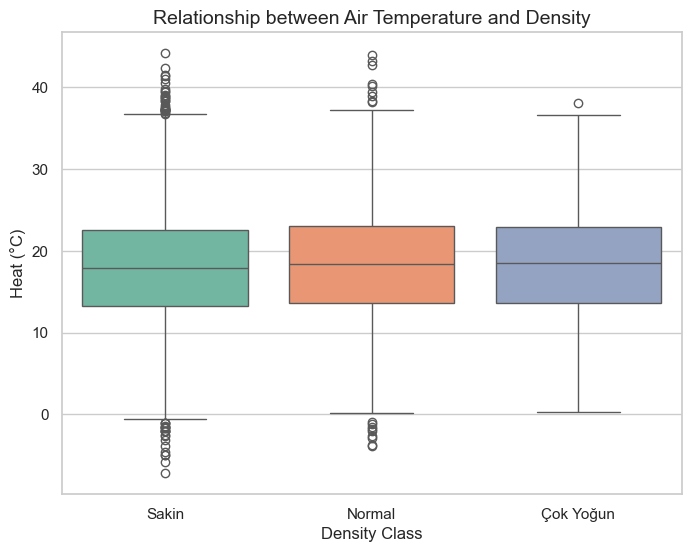

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="density_class", y="heat", order=["Sakin", "Normal", "Çok Yoğun"], palette='Set2')
plt.title("Relationship between Air Temperature and Density", fontsize=14)
plt.xlabel("Density Class", fontsize=12)
plt.ylabel("Heat (°C)", fontsize=12)
plt.show()

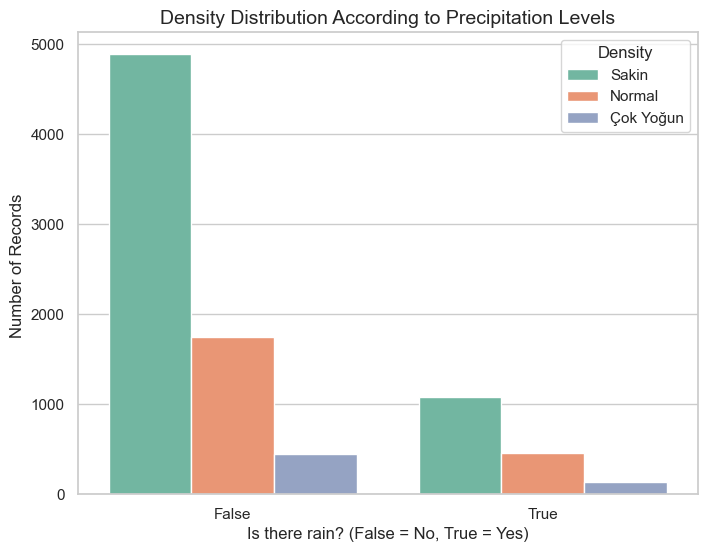

In [22]:
df['is_raining'] = df['rains_mm'] > 0

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='is_raining', hue='density_class', palette='Set2')
plt.title("Density Distribution According to Precipitation Levels", fontsize=14)
plt.xlabel("Is there rain? (False = No, True = Yes)", fontsize=12)
plt.ylabel("Number of Records ", fontsize=12)
plt.legend(title="Density")
plt.show()